# Innovation 1 — Kolmogorov Complexity via Compression

**Principle:** Approximate Kolmogorov complexity using `gzip` compression ratios as a model-independent measure of linguistic/task complexity.

$$K(x) \approx \frac{|\text{gzip}(x)|}{|x|}$$

- **Low ratio** → highly compressible → structurally simple (repetition, predictable patterns)
- **High ratio** → poorly compressible → informationally dense / complex

Validated empirically on EFL learner writing: Kolmogorov complexity via gzip **significantly distinguishes adjacent proficiency levels** better than neural baselines.

**Datasets:** GAIA · AIME · MMLU-Pro · MuSiQue · SWE-Bench

## 0. Imports & Configuration

In [1]:
import gzip
import zlib
import bz2
import lzma
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from typing import Dict, Optional
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
tqdm.pandas()

np.random.seed(42)
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.15)
plt.rcParams.update({"figure.dpi": 130, "figure.facecolor": "white"})

print("✅ Imports complete.")

✅ Imports complete.


/Users/poorna/Downloads/research/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# Dataset Configuration
# ─────────────────────────────────────────────────────────────────────────────

DATA_PATHS: Dict[str, Path] = {
    "gaia"      : Path("../datasets/processed/gaia.parquet"),
    "aime"      : Path("../datasets/processed/aime.parquet"),
    "mmlu_pro"  : Path("../datasets/processed/mmlu_pro.parquet"),
    "musique"   : Path("../datasets/processed/musique.parquet"),
    "swe_bench" : Path("../datasets/processed/swe_bench.parquet"),
}

OUTPUT_DIR = Path("data/processed")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("✅ Configuration set.")
print(f"   Output directory: {OUTPUT_DIR.resolve()}")
print("   Datasets configured:")
for name, path in DATA_PATHS.items():
    exists = "✓" if path.exists() else "✗ (not found)"
    print(f"     {name:<12} → {path}  {exists}")

✅ Configuration set.
   Output directory: /Users/poorna/Downloads/research/notebooks/data/processed
   Datasets configured:
     gaia         → ../datasets/processed/gaia.parquet  ✓
     aime         → ../datasets/processed/aime.parquet  ✓
     mmlu_pro     → ../datasets/processed/mmlu_pro.parquet  ✓
     musique      → ../datasets/processed/musique.parquet  ✓
     swe_bench    → ../datasets/processed/swe_bench.parquet  ✓


## 1. Dataset-Specific Text Extractors

Each benchmark stores task text under different column schemas.  
Each extractor produces a single canonical `task_text` string per row — capturing all complexity-bearing content (question + context + choices where applicable).  
We **never include the answer/solution** to avoid leaking ground truth into the complexity score.

| Dataset | Columns scored | Rationale |
|---------|---------------|----------|
| GAIA | question + annotator metadata | Multi-step tool-use tasks; metadata encodes step count |
| AIME | problem statement | Mathematical reasoning; no solution included |
| MMLU-Pro | question + all options + category | Options expand vocabulary; category anchors domain |
| MuSiQue | question + sub-Qs + all paragraphs | Multi-hop context is core complexity signal |
| SWE-Bench | problem_statement + hints + FAIL_TO_PASS | Code test paths carry structural information |

In [17]:
def _coerce(val) -> str:
    """Safely convert any value to a stripped string. Returns '' for null/NaN."""
    if val is None or (isinstance(val, float) and np.isnan(val)):
        return ""
    return str(val).strip()


def _first_match(row: pd.Series, candidates: list) -> str:
    """Return the first non-empty coerced value from a list of candidate column names."""
    for col in candidates:
        if col in row.index and _coerce(row[col]):
            return _coerce(row[col])
    return ""


# ─────────────────────────────────────────────────────────────────────────────
# GAIA
# Columns: 'Question', 'Level', 'Final answer', 'Annotator Metadata' (dict)
# ─────────────────────────────────────────────────────────────────────────────
def extract_gaia(row: pd.Series) -> str:
    parts = []

    # Primary question text
    q = _first_match(row, ["Question", "question", "input", "task","query"])
    if q:
        parts.append(q)

    # Annotator metadata: steps / tools add task-structure complexity
    if "Annotator Metadata" in row.index and isinstance(row["Annotator Metadata"], dict):
        meta = row["Annotator Metadata"]
        for k in ["Steps", "tools", "Number of steps"]:
            v = _coerce(meta.get(k, ""))
            if v:
                parts.append(f"{k}: {v}")
    elif "annotator_metadata" in row.index and _coerce(row["annotator_metadata"]):
        parts.append(_coerce(row["annotator_metadata"]))

    return "\n".join(parts)


# ─────────────────────────────────────────────────────────────────────────────
# AIME
# Columns: 'problem', 'solution', 'answer', 'year', 'contest'
# ─────────────────────────────────────────────────────────────────────────────
def extract_aime(row: pd.Series) -> str:
    parts = []

    # Problem statement only — solution/answer excluded to avoid leakage
    prob = _first_match(row, ["problem", "Problem", "question", "Question", "input","query"])
    if prob:
        parts.append(prob)

    # Contest context (year / part) is low-information but harmless to include
    for col in ["year", "Year", "contest", "Contest"]:
        if col in row.index and _coerce(row[col]):
            parts.append(f"{col}: {_coerce(row[col])}")

    return "\n".join(parts)


# ─────────────────────────────────────────────────────────────────────────────
# MMLU-Pro
# Columns: 'question', 'options' (list[str]), 'answer', 'category', 'src'
# ─────────────────────────────────────────────────────────────────────────────
def extract_mmlu_pro(row: pd.Series) -> str:
    parts = []

    q = _first_match(row, ["question", "Question", "input","query"])
    if q:
        parts.append(q)

    # All answer options — vocabulary complexity of choices is a real signal
    for col in ["options", "choices", "Options", "Choices"]:
        if col in row.index:
            opts = row[col]
            if isinstance(opts, (list, tuple)):
                for i, opt in enumerate(opts):
                    parts.append(f"({chr(65 + i)}) {_coerce(opt)}")
            elif isinstance(opts, dict):
                for k, v in opts.items():
                    parts.append(f"({k}) {_coerce(v)}")
            elif _coerce(opts):
                parts.append(_coerce(opts))
            break

    # Category / subject as semantic anchor
    cat = _first_match(row, ["category", "Category", "subject"])
    if cat:
        parts.append(f"Category: {cat}")

    return "\n".join(parts)


# ─────────────────────────────────────────────────────────────────────────────
# MuSiQue
# Columns: 'question', 'question_decomposition' (list), 'paragraphs' (list of dicts)
# ─────────────────────────────────────────────────────────────────────────────
def extract_musique(row: pd.Series) -> str:
    parts = []

    q = _first_match(row, ["question", "Question", "input","query"])
    if q:
        parts.append(q)

    # Sub-question decomposition — captures multi-hop reasoning structure
    for col in ["question_decomposition", "decomposition"]:
        if col in row.index:
            decomp = row[col]
            if isinstance(decomp, list):
                for step in decomp:
                    if isinstance(step, dict):
                        sub_q = _coerce(step.get("question", ""))
                        if sub_q:
                            parts.append(f"Sub-Q: {sub_q}")
                    elif _coerce(step):
                        parts.append(f"Sub-Q: {_coerce(step)}")
            break

    # All supporting paragraphs — the full retrieval context is the hardness signal
    for col in ["paragraphs", "context", "passages", "supporting_facts",]:
        if col in row.index:
            ctx = row[col]
            if isinstance(ctx, list):
                for para in ctx:
                    if isinstance(para, dict):
                        title   = _coerce(para.get("title", para.get("idx", "")))
                        content = _coerce(
                            para.get("paragraph_text",
                            para.get("content",
                            para.get("text", "")))
                        )
                        if content:
                            parts.append(f"[{title}] {content}" if title else content)
                    elif _coerce(para):
                        parts.append(_coerce(para))
            elif _coerce(ctx):
                parts.append(_coerce(ctx))
            break

    return "\n".join(parts)


# ─────────────────────────────────────────────────────────────────────────────
# SWE-Bench
# Columns: 'instance_id', 'repo', 'problem_statement', 'hints_text',
#          'FAIL_TO_PASS' (list), 'PASS_TO_PASS' (list)
# ─────────────────────────────────────────────────────────────────────────────
def extract_swe_bench(row: pd.Series) -> str:
    parts = []

    ps = _first_match(row, ["problem_statement", "Problem Statement",
                             "issue", "question", "input", "text"])
    if ps:
        parts.append(ps)

    # Hints add natural language context about what needs fixing
    hints = _first_match(row, ["hints_text", "hints", "Hints"])
    if hints:
        parts.append(f"Hints: {hints}")

    # FAIL_TO_PASS test identifiers carry code-path / module structure information
    for col in ["FAIL_TO_PASS", "fail_to_pass"]:
        if col in row.index and row[col] is not None:
            tests = row[col]
            if isinstance(tests, list) and tests:
                parts.append("FAIL_TO_PASS: " + " ".join(str(t) for t in tests))
            elif _coerce(tests):
                parts.append(f"FAIL_TO_PASS: {_coerce(tests)}")
            break

    repo = _first_match(row, ["repo", "Repo"])
    if repo:
        parts.append(f"repo: {repo}")

    return "\n".join(parts)


# ── Registry ───────────────────────────────────────────────────────────────────
TEXT_EXTRACTORS: Dict[str, callable] = {
    "gaia"      : extract_gaia,
    "aime"      : extract_aime,
    "mmlu_pro"  : extract_mmlu_pro,
    "musique"   : extract_musique,
    "swe_bench" : extract_swe_bench,
}

print("✅ Text extractors defined for all 5 datasets.")

✅ Text extractors defined for all 5 datasets.


## 2. Kolmogorov Complexity Estimators

We define four compressor-based estimators plus an ensemble so results can be cross-validated.

| Column | Algorithm | Notes |
|--------|-----------|-------|
| `kc_gzip` | DEFLATE via gzip | **Primary metric** — arXiv-validated for NLP |
| `kc_zlib` | DEFLATE via zlib | Same algorithm, no file-header overhead |
| `kc_bz2` | Burrows-Wheeler | Better on highly structured/repetitive text |
| `kc_lzma` | LZMA (xz) | Strongest compressor — tightest K(x) upper bound |
| `kc_ensemble` | min(all above) | Closest approximation to true Kolmogorov complexity |

In [18]:
MIN_BYTES = 10  # guard against division-by-zero on trivially short strings


def _encode(text: str) -> bytes:
    try:
        return text.encode("utf-8")
    except Exception:
        return text.encode("utf-8", errors="replace")


def kc_gzip(text: str) -> float:
    """
    PRIMARY estimator: gzip compression ratio (DEFLATE, level 9).
    Returns compressed_size / original_size.  Higher = more complex.
    """
    raw = _encode(text)
    if len(raw) < MIN_BYTES:
        return np.nan
    return len(gzip.compress(raw, compresslevel=9)) / len(raw)


def kc_zlib(text: str) -> float:
    """zlib DEFLATE — no gzip file-header overhead."""
    raw = _encode(text)
    if len(raw) < MIN_BYTES:
        return np.nan
    return len(zlib.compress(raw, level=9)) / len(raw)


def kc_bz2(text: str) -> float:
    """Burrows-Wheeler Transform via bz2."""
    raw = _encode(text)
    if len(raw) < MIN_BYTES:
        return np.nan
    return len(bz2.compress(raw, compresslevel=9)) / len(raw)


def kc_lzma(text: str) -> float:
    """LZMA — strongest compressor; slowest; tightest K(x) upper bound."""
    raw = _encode(text)
    if len(raw) < MIN_BYTES:
        return np.nan
    return len(lzma.compress(raw, preset=9)) / len(raw)


def kc_ensemble(text: str) -> float:
    """
    Ensemble estimate: minimum compression ratio across all compressors.
    Theoretically the closest available approximation to K(x).
    """
    ratios = [kc_gzip(text), kc_zlib(text), kc_bz2(text), kc_lzma(text)]
    valid  = [r for r in ratios if not np.isnan(r)]
    return min(valid) if valid else np.nan


KC_ESTIMATORS: Dict[str, callable] = {
    "kc_gzip"    : kc_gzip,
    "kc_zlib"    : kc_zlib,
    "kc_bz2"     : kc_bz2,
    "kc_lzma"    : kc_lzma,
    "kc_ensemble": kc_ensemble,
}

# ── Derived size features ──────────────────────────────────────────────────────

def text_length_chars(text: str) -> int:  return len(text)
def text_length_bytes(text: str) -> int:  return len(_encode(text))
def text_length_tokens(text: str) -> int: return len(text.split())

def kc_gzip_absolute(text: str) -> int:
    """Absolute gzip-compressed size in bytes (complements the ratio)."""
    raw = _encode(text)
    if len(raw) < MIN_BYTES:
        return 0
    return len(gzip.compress(raw, compresslevel=9))


# ── Sanity check ───────────────────────────────────────────────────────────────
print("Sanity checks — lower ratio = simpler text:")
samples = {
    "Repetitive text" : "the the the the the the the the the the" * 20,
    "Natural prose"   : "The mitochondria is the powerhouse of the cell. " * 10,
    "Math problem"    : "Let f(x) = x^3 - 2x + 1. Find all real roots of f'(x) = 0 and classify each critical point using the second derivative test.",
    "Code snippet"    : "def solve(n):\n    return sum(i*i for i in range(n) if i % 2 == 0)\nassert solve(5) == 20\n" * 3,
    "Pseudo-random"   : "".join(np.random.choice(list("abcdefghijklmnopqrstuvwxyz "), size=400)),
}
rows = []
for label, txt in samples.items():
    rows.append({"Sample": label, "Chars": len(txt),
                 **{k: round(fn(txt), 4) for k, fn in KC_ESTIMATORS.items()}})
pd.set_option("display.float_format", "{:.4f}".format)
display(pd.DataFrame(rows).set_index("Sample"))

Sanity checks — lower ratio = simpler text:


,Chars,kc_gzip,kc_zlib,kc_bz2,kc_lzma,kc_ensemble
Sample,,,,,,
Repetitive text,780,0.0436,0.0282,0.0654,0.1026,0.0282
Natural prose,480,0.1437,0.1187,0.2229,0.2417,0.1187
Math problem,124,0.9919,0.8952,1.0968,1.4516,0.8952
Code snippet,264,0.3788,0.3333,0.4886,0.5606,0.3333
Pseudo-random,400,0.6975,0.6675,0.7650,0.9000,0.6675


## 3. Scoring Pipeline

In [19]:
def score_dataset(
    name       : str,
    path       : Path,
    extractor  : callable,
    estimators : Dict[str, callable] = KC_ESTIMATORS,
    output_dir : Path = OUTPUT_DIR,
) -> Optional[pd.DataFrame]:
    """
    Load a parquet file, extract task text, compute all KC estimators,
    and write an enriched parquet to output_dir.

    New columns added
    -----------------
    task_text      : canonical extracted text (input to all KC functions)
    text_chars     : raw character count
    text_bytes     : UTF-8 byte count
    text_tokens    : whitespace-split token count (fast approximation)
    kc_gzip        : gzip compression ratio  ← PRIMARY metric
    kc_zlib        : zlib compression ratio
    kc_bz2         : bz2 compression ratio
    kc_lzma        : lzma compression ratio
    kc_ensemble    : min(all ratios) — tightest KC upper bound
    kc_gzip_bytes  : absolute compressed size in bytes
    kc_gzip_pct    : within-dataset percentile rank 0–100
    """
    if not path.exists():
        print(f"  ⚠️  [{name}] File not found: {path} — skipping.")
        return None

    print(f"\n{'─' * 60}")
    print(f"  📂  Loading: {name}")
    df = pd.read_parquet(path)
    print(f"      Rows: {len(df):,}   Columns: {list(df.columns)}")

    # 1. Extract task text
    print("      Extracting task text...")
    df["task_text"] = df.progress_apply(extractor, axis=1)
    n_empty = (df["task_text"].str.strip() == "").sum()
    if n_empty:
        print(f"      ⚠️  {n_empty}/{len(df)} rows produced empty task_text — check extractor.")

    # 2. Raw length features
    df["text_chars"]  = df["task_text"].apply(text_length_chars)
    df["text_bytes"]  = df["task_text"].apply(text_length_bytes)
    df["text_tokens"] = df["task_text"].apply(text_length_tokens)

    # 3. KC estimators
    print(f"      Computing KC estimators: {list(estimators.keys())} ...")
    for col, fn in estimators.items():
        df[col] = df["task_text"].progress_apply(fn)

    # 4. Absolute compressed size
    df["kc_gzip_bytes"] = df["task_text"].apply(kc_gzip_absolute)

    # 5. Within-dataset percentile rank (0–100)
    df["kc_gzip_pct"] = df["kc_gzip"].rank(pct=True) * 100

    # 6. Summary
    kc_cols = list(estimators.keys())
    print(f"\n      KC summary ({name}):")
    display(
        df[kc_cols + ["text_tokens"]]
        .describe(percentiles=[0.25, 0.5, 0.75, 0.95])
        .round(4)
    )

    # 7. Save
    out_path = output_dir / f"{name}_kc_scored.parquet"
    df.to_parquet(out_path, index=False)
    print(f"\n      ✅  Saved → {out_path}")
    return df


print("✅ Scoring pipeline defined.")

✅ Scoring pipeline defined.


## 4. Run Scoring on All Datasets

In [20]:
scored: Dict[str, pd.DataFrame] = {}

for ds_name, ds_path in DATA_PATHS.items():
    df_scored = score_dataset(
        name       = ds_name,
        path       = ds_path,
        extractor  = TEXT_EXTRACTORS[ds_name],
        estimators = KC_ESTIMATORS,
        output_dir = OUTPUT_DIR,
    )
    if df_scored is not None:
        scored[ds_name] = df_scored

print(f"\n{'═' * 60}")
print(f"  Completed: {len(scored)}/{len(DATA_PATHS)} datasets scored.")
for name, df in scored.items():
    print(f"    {name:<12}: {len(df):>6,} rows")


────────────────────────────────────────────────────────────
  📂  Loading: gaia
      Rows: 165   Columns: ['id', 'query', 'answer', 'level', 'annotator_steps', 'annotator_tools', 'file_name']
      Extracting task text...


100%|██████████| 165/165 [00:00<00:00, 13554.92it/s]


      Computing KC estimators: ['kc_gzip', 'kc_zlib', 'kc_bz2', 'kc_lzma', 'kc_ensemble'] ...


100%|██████████| 165/165 [00:00<00:00, 302.70it/s]


      KC summary (gaia):


...

      Computing KC estimators: ['kc_gzip', 'kc_zlib', 'kc_bz2', 'kc_lzma', 'kc_ensemble'] ...


100%|██████████| 500/500 [00:01<00:00, 292.10it/s]


      KC summary (swe_bench):


,kc_gzip,kc_zlib,kc_bz2,kc_lzma,kc_ensemble,text_tokens
count,500.0000,500.0000,500.0000,500.0000,500.0000,500.0000
mean,0.7118,0.6589,0.8359,0.9290,0.6587,161.5820
std,0.2782,0.2252,0.3684,0.4766,0.2255,300.2540
min,0.1034,0.1026,0.1102,0.1059,0.1026,4.0000
25%,0.4895,0.4780,0.5527,0.5548,0.4780,5.0000
50%,0.6595,0.6303,0.7444,0.7990,0.6303,49.0000
75%,0.9477,0.8574,1.0960,1.2986,0.8574,176.2500
95%,1.2144,1.0469,1.5599,1.8835,1.0469,778.8000
max,1.3556,1.0889,1.9556,2.3111,1.0889,2343.0000



      ✅  Saved → data/processed/swe_bench_kc_scored.parquet

════════════════════════════════════════════════════════════
  Completed: 5/5 datasets scored.
    gaia        :    165 rows
    aime        :     30 rows
    mmlu_pro    : 12,032 rows
    musique     :  2,417 rows
    swe_bench   :    500 rows


## 5. Cross-Dataset Analysis & Visualisation

In [21]:
# ── 5.1  Summary table ────────────────────────────────────────────────────────

summary_rows = []
for ds_name, df in scored.items():
    summary_rows.append({
        "Dataset"           : ds_name,
        "N"                 : len(df),
        "median_tokens"     : round(df["text_tokens"].median(), 1),
        "median_kc_gzip"    : round(df["kc_gzip"].median(), 4),
        "mean_kc_gzip"      : round(df["kc_gzip"].mean(), 4),
        "std_kc_gzip"       : round(df["kc_gzip"].std(), 4),
        "p25_kc_gzip"       : round(df["kc_gzip"].quantile(0.25), 4),
        "p75_kc_gzip"       : round(df["kc_gzip"].quantile(0.75), 4),
        "median_kc_ensemble": round(df["kc_ensemble"].median(), 4),
    })

summary_df = pd.DataFrame(summary_rows).set_index("Dataset")
print("Cross-dataset KC Summary")
print("Higher median_kc_gzip → harder to compress → more informationally complex\n")
display(summary_df)

Cross-dataset KC Summary
Higher median_kc_gzip → harder to compress → more informationally complex



,N,median_tokens,median_kc_gzip,mean_kc_gzip,std_kc_gzip,p25_kc_gzip,p75_kc_gzip,median_kc_ensemble
Dataset,,,,,,,,
gaia,165,39.0000,0.7695,0.7853,0.1624,0.6740,0.8696,0.7172
aime,30,57.0000,0.6944,0.7191,0.1460,0.6202,0.8050,0.6494
mmlu_pro,12032,77.0000,0.5726,0.5799,0.1654,0.4526,0.6930,0.5485
musique,2417,1813.0000,0.4004,0.3967,0.0300,0.3793,0.4181,0.3796
swe_bench,500,49.0000,0.6595,0.7118,0.2782,0.4895,0.9477,0.6303


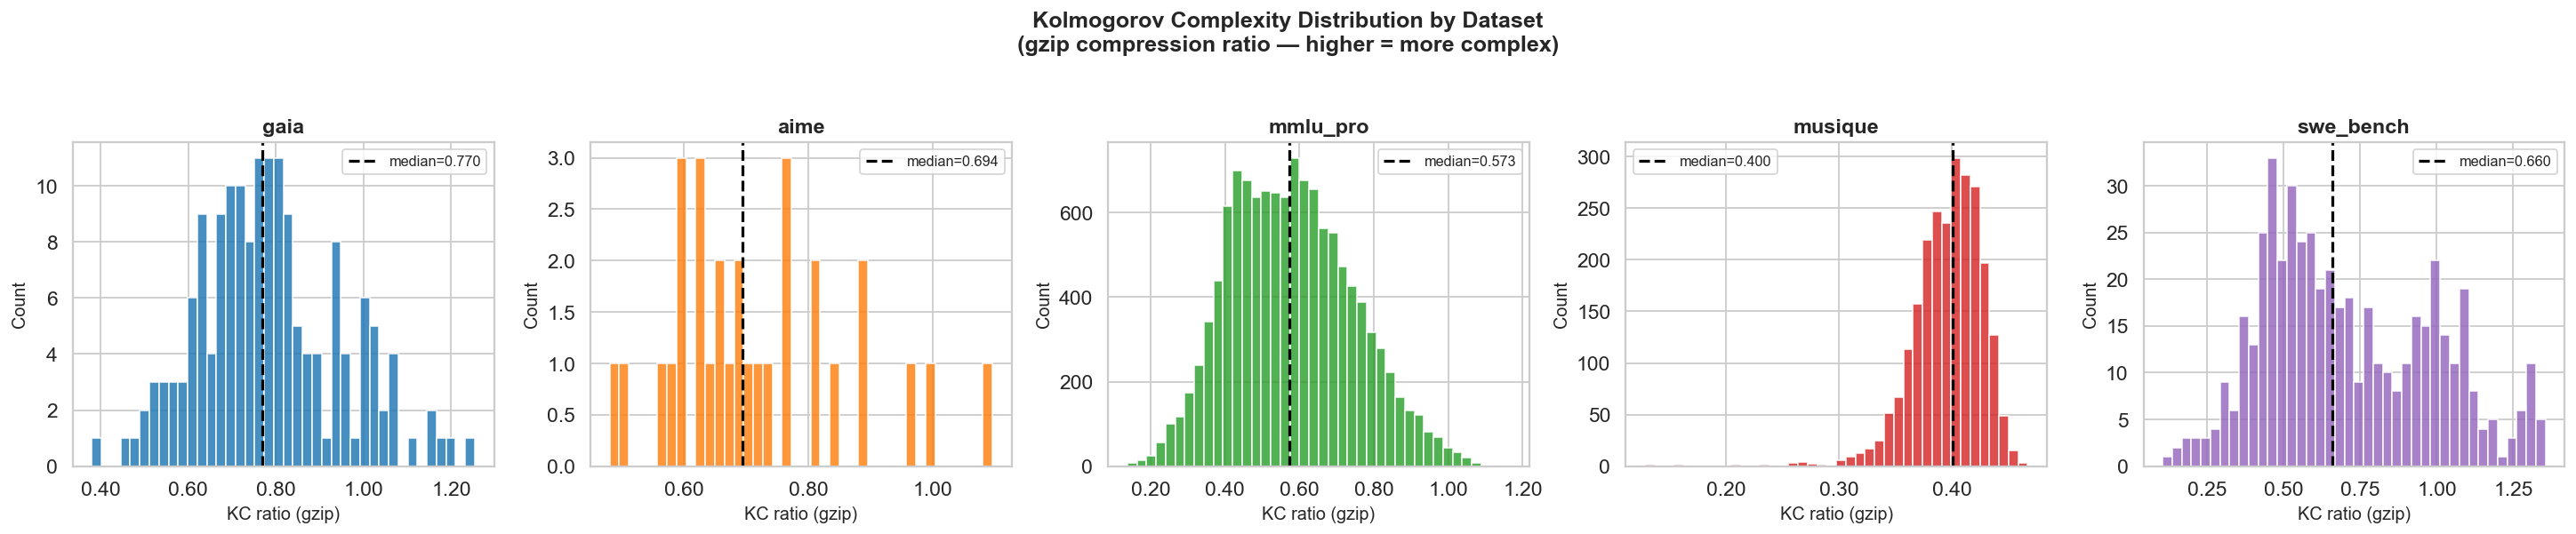

✅ Plot saved.


In [22]:
# ── 5.2  Per-dataset KC distributions ─────────────────────────────────────────

if scored:
    palette = sns.color_palette("tab10", n_colors=len(scored))
    fig, axes = plt.subplots(1, len(scored), figsize=(4.5 * len(scored), 4.5), sharey=False)
    if len(scored) == 1:
        axes = [axes]

    for ax, (ds_name, df), color in zip(axes, scored.items(), palette):
        vals = df["kc_gzip"].dropna()
        ax.hist(vals, bins=40, color=color, alpha=0.82, edgecolor="white")
        ax.axvline(vals.median(), color="black", linewidth=1.8,
                   linestyle="--", label=f"median={vals.median():.3f}")
        ax.set_title(ds_name, fontweight="bold", fontsize=13)
        ax.set_xlabel("KC ratio (gzip)", fontsize=11)
        ax.set_ylabel("Count", fontsize=11)
        ax.legend(fontsize=9)
        ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))

    plt.suptitle(
        "Kolmogorov Complexity Distribution by Dataset\n"
        "(gzip compression ratio — higher = more complex)",
        fontsize=14, fontweight="bold", y=1.03,
    )
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "kc_distribution_by_dataset.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("✅ Plot saved.")

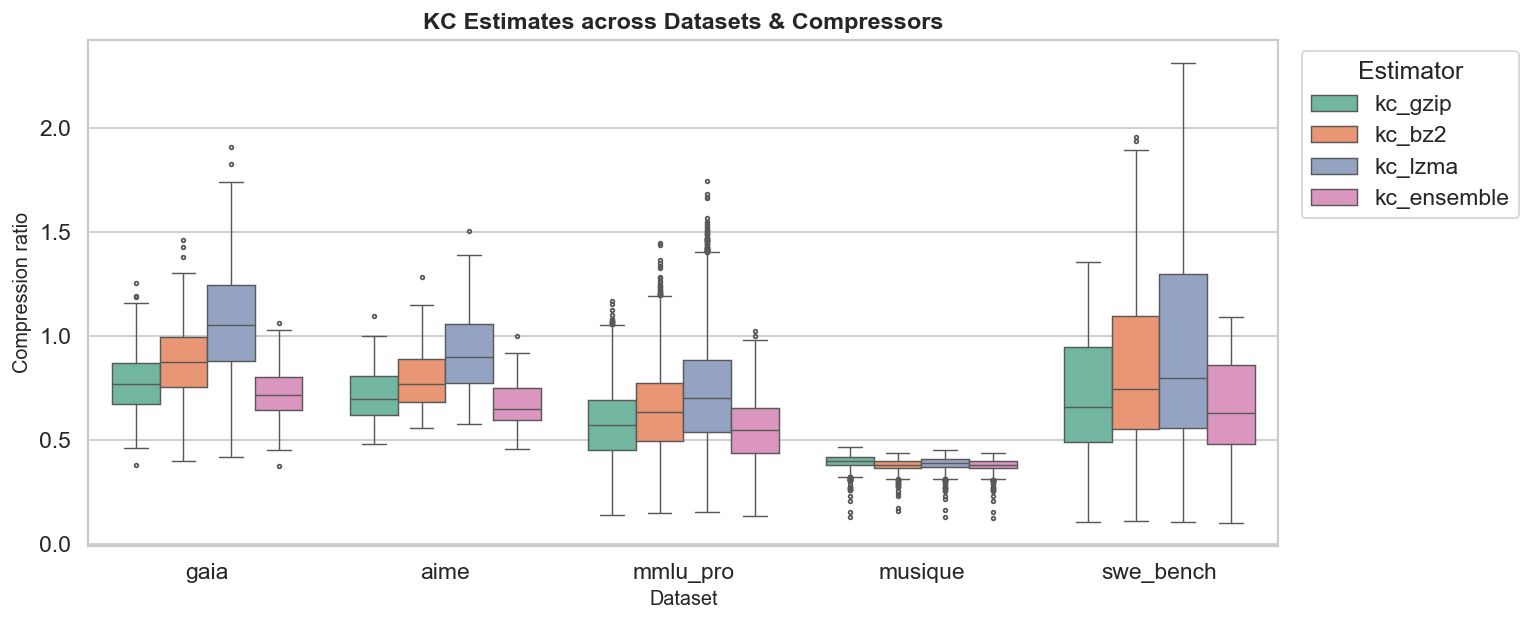

In [23]:
# ── 5.3  Box-plot: multi-compressor comparison across datasets ─────────────────

if scored:
    combined_long = pd.concat(
        [
            df[["kc_gzip", "kc_bz2", "kc_lzma", "kc_ensemble"]]
            .assign(dataset=ds_name)
            for ds_name, df in scored.items()
        ],
        ignore_index=True,
    ).melt(id_vars="dataset", var_name="estimator", value_name="kc_ratio")

    fig, ax = plt.subplots(figsize=(12, 5))
    sns.boxplot(
        data=combined_long, x="dataset", y="kc_ratio", hue="estimator",
        palette="Set2", fliersize=2, linewidth=0.8, ax=ax,
    )
    ax.set_title("KC Estimates across Datasets & Compressors", fontweight="bold", fontsize=13)
    ax.set_xlabel("Dataset", fontsize=11)
    ax.set_ylabel("Compression ratio", fontsize=11)
    ax.legend(title="Estimator", bbox_to_anchor=(1.01, 1), loc="upper left")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "kc_cross_dataset_boxplot.png", dpi=150, bbox_inches="tight")
    plt.show()

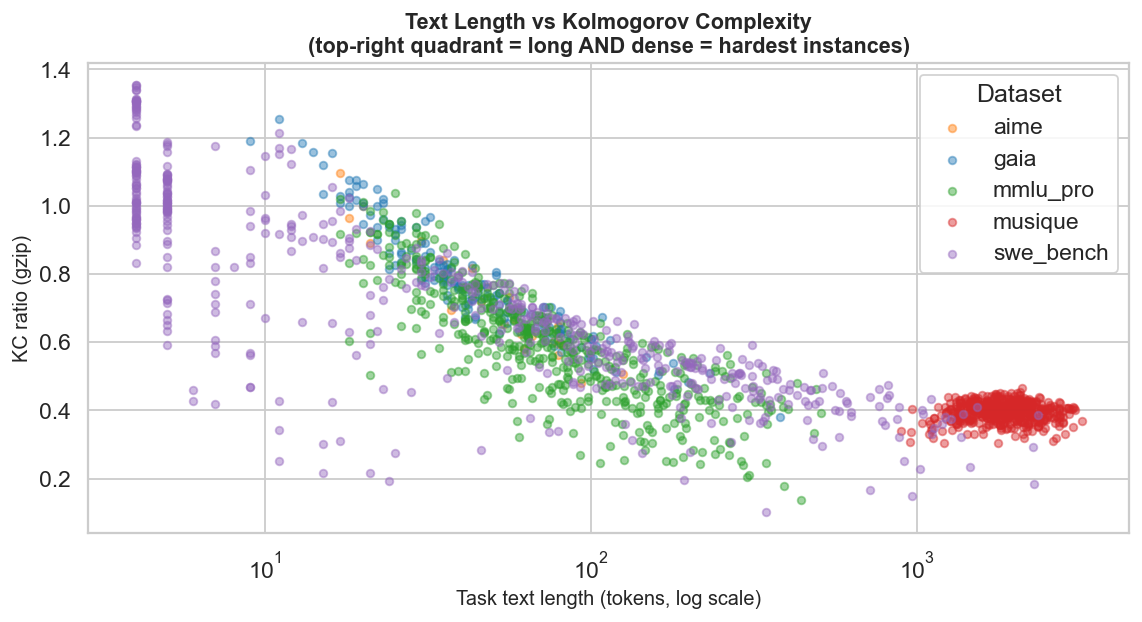

In [24]:
# ── 5.4  Scatter: text length vs KC ratio ──────────────────────────────────────

if scored:
    combined_all = pd.concat(
        [df.assign(dataset=ds_name) for ds_name, df in scored.items()],
        ignore_index=True,
    )
    palette_ds = dict(zip(scored.keys(), sns.color_palette("tab10", len(scored))))

    fig, ax = plt.subplots(figsize=(9, 5))
    for ds_name, group in combined_all.groupby("dataset"):
        plot_group = group.sample(min(len(group), 500), random_state=42)
        ax.scatter(
            plot_group["text_tokens"], plot_group["kc_gzip"],
            alpha=0.45, s=18, color=palette_ds[ds_name], label=ds_name,
        )
    ax.set_xscale("log")
    ax.set_xlabel("Task text length (tokens, log scale)", fontsize=11)
    ax.set_ylabel("KC ratio (gzip)", fontsize=11)
    ax.set_title(
        "Text Length vs Kolmogorov Complexity\n"
        "(top-right quadrant = long AND dense = hardest instances)",
        fontsize=12, fontweight="bold",
    )
    ax.legend(title="Dataset", framealpha=0.85)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "kc_vs_length_scatter.png", dpi=150, bbox_inches="tight")
    plt.show()

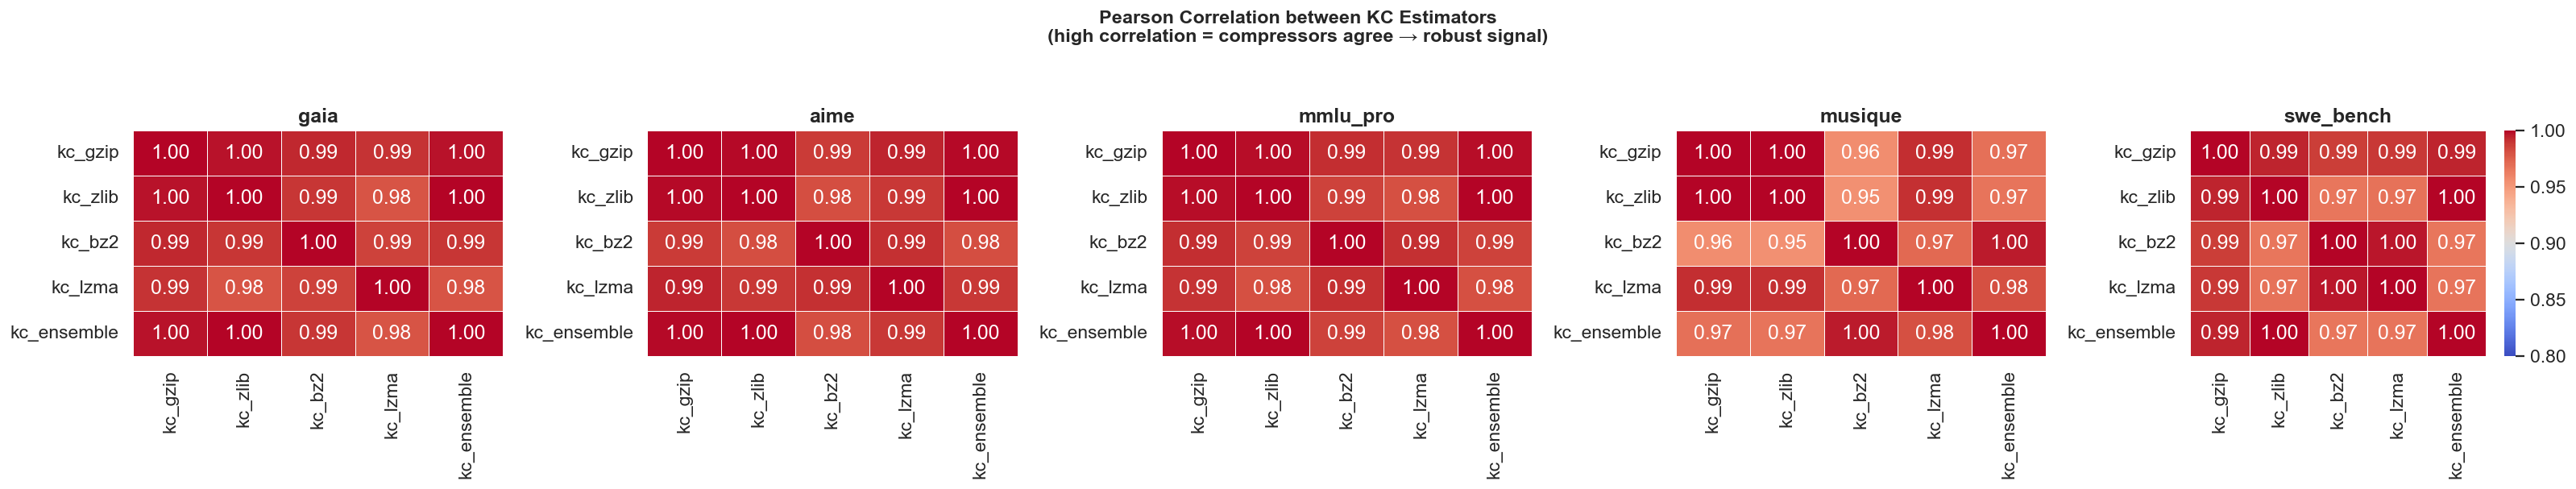

In [25]:
# ── 5.5  Pearson correlation between compressors (validates consistency) ────────

if scored:
    kc_cols = ["kc_gzip", "kc_zlib", "kc_bz2", "kc_lzma", "kc_ensemble"]
    n_ds = len(scored)
    fig, axes = plt.subplots(1, n_ds, figsize=(5 * n_ds, 4.5), squeeze=False)

    for ax_col, (ds_name, df) in enumerate(scored.items()):
        ax = axes[0][ax_col]
        corr = df[kc_cols].corr(method="pearson")
        sns.heatmap(
            corr, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=0.8, vmax=1.0, linewidths=0.5,
            ax=ax, cbar=(ax_col == n_ds - 1),
        )
        ax.set_title(ds_name, fontweight="bold")

    plt.suptitle(
        "Pearson Correlation between KC Estimators\n"
        "(high correlation = compressors agree → robust signal)",
        fontsize=13, fontweight="bold", y=1.04,
    )
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "kc_estimator_correlation.png", dpi=150, bbox_inches="tight")
    plt.show()

## 6. Per-Dataset Deep-Dive: Hardest & Easiest Instances

In [26]:
PREVIEW_LEN = 280  # max chars to display from task_text preview

for ds_name, df in scored.items():
    df_valid = df.dropna(subset=["kc_gzip"]).copy()
    if df_valid.empty:
        continue

    print(f"\n{'═' * 65}")
    print(f"  {ds_name.upper()}  —  {len(df_valid):,} instances")
    print(f"  KC range: [{df_valid['kc_gzip'].min():.4f}, {df_valid['kc_gzip'].max():.4f}]")

    for label, subset in [
        ("🔴 Most complex   (top 3 by kc_gzip)"   , df_valid.nlargest(3, "kc_gzip")),
        ("🟢 Least complex  (bottom 3 by kc_gzip)", df_valid.nsmallest(3, "kc_gzip")),
    ]:
        print(f"\n  {label}")
        for _, row in subset.iterrows():
            preview = row["task_text"][:PREVIEW_LEN].replace("\n", " ")
            if len(row["task_text"]) > PREVIEW_LEN:
                preview += "…"
            print(f"    kc_gzip={row['kc_gzip']:.4f}  "
                  f"kc_ensemble={row['kc_ensemble']:.4f}  "
                  f"tokens={row['text_tokens']}")
            print(f"    {preview}")
            print()


═════════════════════════════════════════════════════════════════
  GAIA  —  165 instances
  KC range: [0.3802, 1.2540]

  🔴 Most complex   (top 3 by kc_gzip)
    kc_gzip=1.2540  kc_ensemble=1.0635  tokens=11
    What is the final numeric output from the attached Python code?

    kc_gzip=1.1912  kc_ensemble=1.0147  tokens=9
    How many slides in this PowerPoint presentation mention crustaceans?

    kc_gzip=1.1842  kc_ensemble=1.0263  tokens=13
    How many images are there in the latest 2022 Lego english wikipedia article?


  🟢 Least complex  (bottom 3 by kc_gzip)
    kc_gzip=0.3802  kc_ensemble=0.3744  tokens=380
    Here's a fun riddle that I think you'll enjoy.  You have been selected to play the final round of the hit new game show "Pick That Ping-Pong". In this round, you will be competing for a large cash prize. Your job will be to pick one of several different numbered ping-pong balls, …

    kc_gzip=0.4628  kc_ensemble=0.4507  tokens=179
    In the fictional language of Ti

## 7. KC-Stratified Sampling

Draw **complexity-stratified** samples — useful for creating balanced evaluation subsets
that span the full difficulty spectrum rather than sampling uniformly.

## 8. Output Manifest

In [28]:
print(f"\n{'═' * 65}")
print(f"  OUTPUT MANIFEST — {OUTPUT_DIR.resolve()}")
print(f"{'═' * 65}")

all_outputs = sorted(OUTPUT_DIR.glob("*.parquet")) + sorted(OUTPUT_DIR.glob("*.png"))
for f in all_outputs:
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name:<50}  {size_kb:>8.1f} KB")

print("\n  New columns in each *_kc_scored.parquet:")
for c in [
    "task_text       — canonical extracted task text (no answer)",
    "text_chars      — character count",
    "text_bytes      — UTF-8 byte count",
    "text_tokens     — whitespace token count (fast)",
    "kc_gzip         — gzip compression ratio   ← PRIMARY metric",
    "kc_zlib         — zlib compression ratio",
    "kc_bz2          — bz2 compression ratio",
    "kc_lzma         — lzma compression ratio",
    "kc_ensemble     — min(all ratios) — tightest KC upper bound",
    "kc_gzip_bytes   — absolute compressed byte count",
    "kc_gzip_pct     — within-dataset percentile rank 0–100",
]:
    print(f"    + {c}")

print("\n✅  All done.")


═════════════════════════════════════════════════════════════════
  OUTPUT MANIFEST — /Users/poorna/Downloads/research/notebooks/data/processed
═════════════════════════════════════════════════════════════════
  aime_complexity.parquet                                 86.1 KB
  aime_kc_scored.parquet                                  96.0 KB
  all_datasets_complexity_summary.parquet                  8.4 KB
  gaia_complexity.parquet                                121.5 KB
  gaia_kc_scored.parquet                                 159.0 KB
  mmlu_pro_complexity.parquet                           3960.8 KB
  mmlu_pro_kc_scored.parquet                            8281.6 KB
  musique_complexity.parquet                           11431.4 KB
  musique_kc_scored.parquet                            23478.1 KB
  swe_bench_complexity.parquet                          1735.9 KB
  swe_bench_kc_scored.parquet                           2070.8 KB
  kc_cross_dataset_boxplot.png                            56.9 